### Section 2.5 Écoulement de deux fluides visqueux adjacents sur un plan.
> Pour cet exemple on ira directement à l'équation diférentielle puisqu'on a déjà fait le même type de bilans à la section 2.2 en détails. 


><img src='Chap-2-Section-2-5.png'>


In [12]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)

In [13]:
# définition des variables symboliques et des lois de Newton, voir figure ci-haut
x,p_0,p_L,mu1,mu2,L,B=sp.symbols('x,p_0,p_L,mu_I,mu_II,L,B')
tau_xz1=sp.symbols('tau_xz^I')
tau_xz2=sp.symbols('tau_xz^II')
C11,C12,C21,C22,C1,C2=sp.symbols('C_11,C_12,C_21,C_22,C1,C2')
vz1=sp.Function('v_z^I')(x)
vz2=sp.Function('v_z^II')(x)
#
# Lois de Newton
#
newton1=-mu1*sp.Derivative(vz1,x) 
newton2=-mu2*sp.Derivative(vz2,x)

#### Le bilan est identique à celui fait dans la section 2, sans la gravité, alors le résultat est simple, pour chacun des deux fluides on a le résultat du bilan montré sur la figure ci-haut:

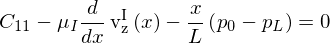

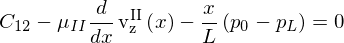

In [14]:
# Bilan des forces
eq1=sp.Eq(tau_xz1(x)-(p_0-p_L)*x/L+C11)
eq2=sp.Eq(tau_xz2(x)-(p_0-p_L)*x/L+C12)
eq1=eq1.subs(tau_xz1(x),newton1)
eq2=eq2.subs(tau_xz2(x),newton2)
display(eq1)
display(eq2)

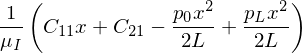

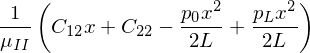

In [15]:
vz1=sp.dsolve(eq1.lhs,vz1)
vz2=sp.dsolve(eq2.lhs,vz2)
#
# Chaque dsolve génère une nouvelle constante par intégration, On les renomme ici pour respecter notre 
# convention. Vous pouvez vérifier en faisant display des vz avant ces remplacements. On veut avoir
# la même notation que celle de Transport Phenomena autant que possible.
vz1=vz1.subs(C1,C21)
vz2=vz2.subs(C1,C22)
vz1=vz1.rhs                  # à droite du signe d'égalité
vz2=vz2.rhs
display(vz1)
display(vz2)                

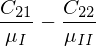

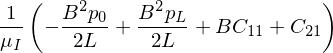

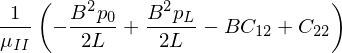

In [16]:
# On peut solutionner directement les 4 constantes avec les 4 conditions aux limites
#
# Ici étant donné qu'on travaille avec sympy qui fera la solution automatiquement, on ne se préocuppe
# pas de décomposer le problème en plusieurs morceaux, on va directement à 4 équations et 4 inconnues.
#
#
eq1=vz1.subs(x,0)-vz2.subs(x,0)                                 # vitesses égales à l'interface
eq2=mu1*sp.diff(vz1,x).subs(x,0)-mu2*sp.diff(vz2,x).subs(x,0)   # cisaillement égaux
eq3=sp.Eq(vz1.subs(x,B),0).lhs                                  # non glissement
eq4=sp.Eq(vz2.subs(x,-B),0).lhs                                 # non glissement
display(eq1)
display(eq2)
display(eq3)
display(eq4)

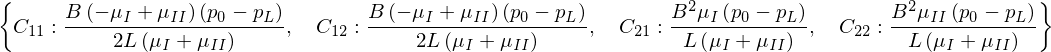

In [17]:
constantes=sp.solve([eq1,eq2,eq3,eq4],sp.symbols('C_11,C_12,C_21,C_22')) 
display(constantes)

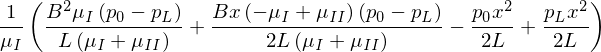

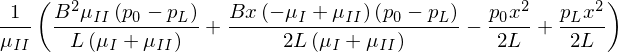

In [18]:
vz1=vz1.subs(constantes)
vz2=vz2.subs(constantes)
display(vz1)
display(vz2)

### Maintenant on tracera les profils en variant les viscosités.

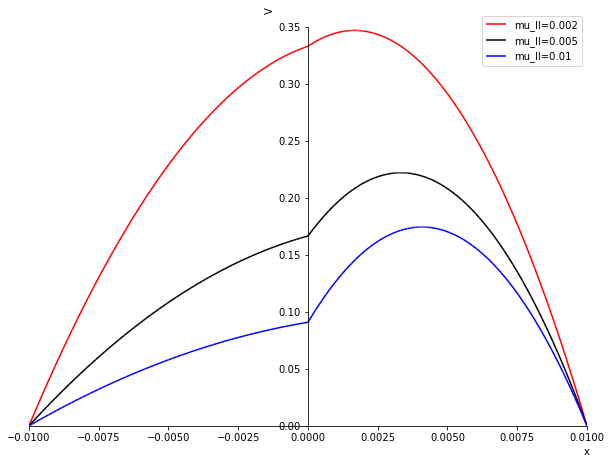

In [24]:
dico1={'mu_I':0.001,'mu_II':0.002,'B':0.01, 'L':10,'p_0':100,'p_L':0}
dico2={'mu_I':0.001,'mu_II':0.005,'B':0.01, 'L':10,'p_0':100,'p_L':0}
dico3={'mu_I':0.001,'mu_II':0.010,'B':0.01, 'L':10,'p_0':100,'p_L':0}
vz1p1=vz1.subs(dico1)
vz2p1=vz2.subs(dico1)
vz1p2=vz1.subs(dico2)
vz2p2=vz2.subs(dico2)
vz1p3=vz1.subs(dico3)
vz2p3=vz2.subs(dico3)
B=B.subs(dico1)                           # B est le même dans les 3 dicos...
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
p=sp.plot((vz1p1,(x,0,B)),(vz2p1,(x,-B,0)), 
        (vz1p2,(x,0,B)),(vz2p2,(x,-B,0)),
        (vz1p3,(x,0,B)),(vz2p3,(x,-B,0)),ylabel='V',legend=True,show=False)
p[0].label='mu_II=0.002'
p[0].line_color='red'
p[1].label=''
p[1].line_color='red'
p[2].label='mu_II=0.005'
p[2].line_color='black'
p[3].label=''
p[3].line_color='black'
p[4].label='mu_II=0.01'
p[4].line_color='blue'
p[5].label=''
p[5].line_color='blue'
p.show()